# Задание 4 — Логистика и поставки


In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'psycopg2-binary', 'boto3', 'pyarrow', 's3fs', '--quiet'], check=True)


CompletedProcess(args=['/opt/conda/bin/python', '-m', 'pip', 'install', 'psycopg2-binary', 'boto3', 'pyarrow', 's3fs', '--quiet'], returncode=0)

In [2]:
import os, io, warnings
import boto3
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

PG_URI = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','oilfield')}:{os.getenv('PG_PASSWORD','oilfield123')}"
    f"@{os.getenv('PG_HOST','postgres')}:{os.getenv('PG_PORT','5432')}"
    f"/{os.getenv('PG_DB','oilfield')}"
)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT',   'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY', 'minioadmin123')
BUCKET           = os.getenv('MINIO_BUCKET',     'oilfield')

engine = create_engine(PG_URI)

s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
)

def read_parquet(bucket, prefix):
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in resp.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            buf = io.BytesIO()
            s3.download_fileobj(bucket, obj['Key'], buf)
            buf.seek(0)
            frames.append(pq.read_table(buf).to_pandas())
    return pd.concat(frames, ignore_index=True)



## 1. Загрузка данных


In [3]:
df = read_parquet(BUCKET, 'deliveries/')
df['planned_date'] = pd.to_datetime(df['planned_date'])
df['actual_date']  = pd.to_datetime(df['actual_date'])

if 'cost_per_km' not in df.columns:
    df['cost_per_km'] = (df['cost_rub'] / df['distance_km']).round(2)

print(f'Deliveries: {df.shape}')
display(df.head())
print('\nПогодные условия:')
print(df['weather'].value_counts())
print('\nТипы дорог:')
print(df['road_type'].value_counts())

Deliveries: (300, 18)


,delivery_id,route_id,driver_id,origin,destination,distance_km,volume_t,cost_rub,planned_date,actual_date,delay_days,weather,road_type,cost_per_km,delay_flag,volume_flag,year,month
0,1,RT-002,12,Нижневартовск,Тюмень,690.20,19.959,88865.63,2025-11-30,2025-12-03,3,snow,highway,128.75,1,medium,2025,11
1,2,RT-003,11,Нижневартовск,Омск,711.19,46.191,97209.93,2025-11-30,2025-12-06,6,snow,highway,136.69,1,large,2025,11
2,3,RT-004,5,Нижневартовск,Екатеринбург,113.72,17.057,36016.45,2025-11-30,2025-12-03,3,snow,highway,316.71,1,medium,2025,11
3,4,RT-005,9,Нижневартовск,Пермь,774.06,24.245,15088.89,2025-11-30,2025-12-03,3,snow,highway,19.49,1,medium,2025,11
4,5,RT-006,8,Нижневартовск,Уфа,532.94,38.808,75403.05,2025-11-30,2025-12-04,4,snow,highway,141.49,1,large,2025,11



Погодные условия:
weather
clear    100
snow      75
rain      75
fog       50
Name: count, dtype: int64

Типы дорог:
road_type
highway    125
offroad    100
gravel      75
Name: count, dtype: int64


## 2. EDA — распределение задержек


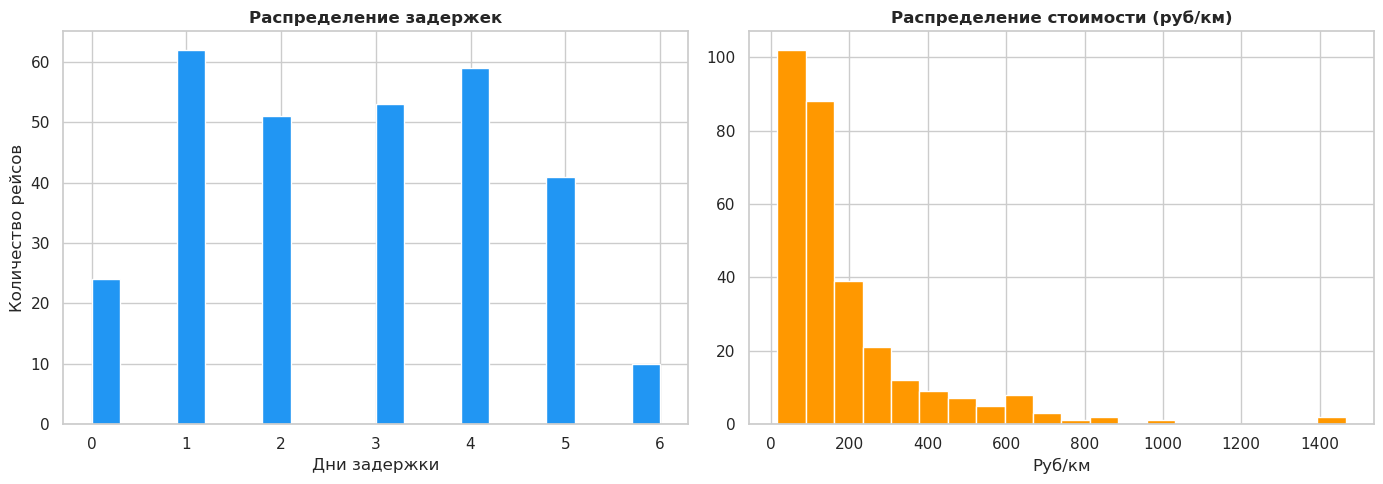


Процент рейсов с задержкой: 92.0%
Средняя задержка: 2.75 дней


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['delay_days'].hist(bins=20, ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Распределение задержек', fontweight='bold')
axes[0].set_xlabel('Дни задержки')
axes[0].set_ylabel('Количество рейсов')

df['cost_per_km'].hist(bins=20, ax=axes[1], color='#FF9800', edgecolor='white')
axes[1].set_title('Распределение стоимости (руб/км)', fontweight='bold')
axes[1].set_xlabel('Руб/км')

plt.tight_layout()
plt.show()

print(f'\nПроцент рейсов с задержкой: {(df["delay_days"] > 0).mean()*100:.1f}%')
print(f'Средняя задержка: {df["delay_days"].mean():.2f} дней')

## 3. График 1 — Задержки по погоде


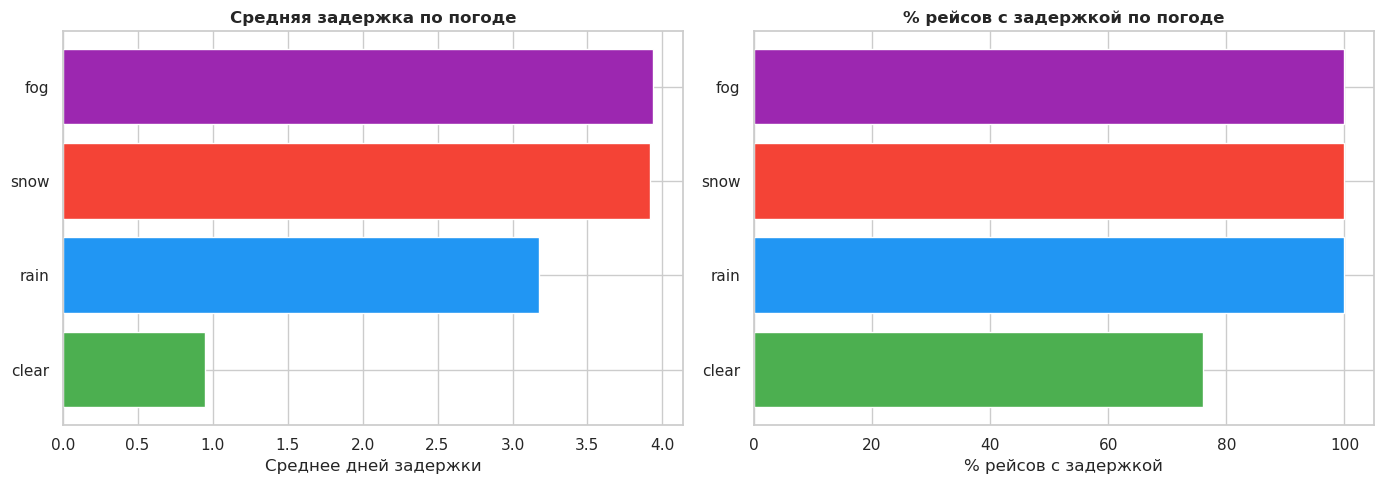

,weather,avg_delay,max_delay,pct_delayed,count
0,clear,0.950000,2,76.0,100
2,rain,3.173333,5,100.0,75
3,snow,3.920000,6,100.0,75
1,fog,3.940000,6,100.0,50


In [5]:
weather_delay = (
    df.groupby('weather')
    .agg(avg_delay=('delay_days','mean'),
         max_delay=('delay_days','max'),
         pct_delayed=('delay_days', lambda x: (x>0).mean()*100),
         count=('delivery_id','count'))
    .reset_index().sort_values('avg_delay', ascending=True)
)

palette = {'clear':'#4CAF50','rain':'#2196F3','fog':'#9C27B0','snow':'#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [palette.get(w, '#666') for w in weather_delay['weather']]
axes[0].barh(weather_delay['weather'], weather_delay['avg_delay'], color=colors)
axes[0].set_title('Средняя задержка по погоде', fontweight='bold')
axes[0].set_xlabel('Среднее дней задержки')

axes[1].barh(weather_delay['weather'], weather_delay['pct_delayed'], color=colors)
axes[1].set_title('% рейсов с задержкой по погоде', fontweight='bold')
axes[1].set_xlabel('% рейсов с задержкой')

plt.tight_layout()
plt.show()
display(weather_delay)

## 4. График 2 — Cost vs Distance


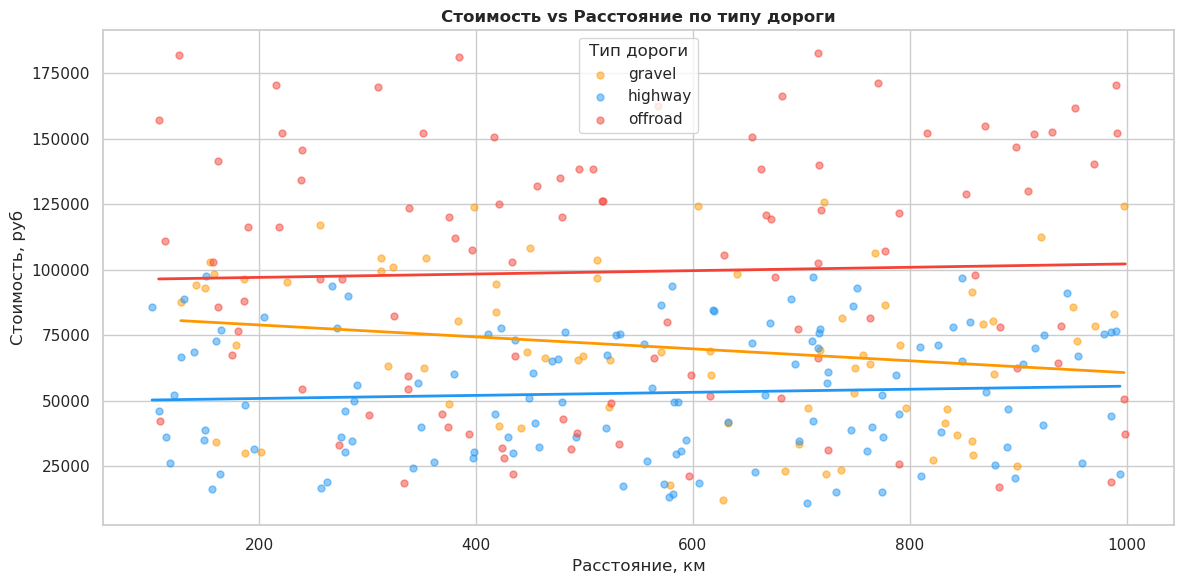


Средняя стоимость за км по типу дороги:


,count,mean,std,min,25%,50%,75%,max
road_type,,,,,,,,
gravel,75.0,176.55,165.17,19.16,78.50,120.50,204.27,686.60
highway,125.0,137.18,139.44,15.72,65.34,92.98,141.49,848.33
offroad,100.0,260.05,256.90,19.32,104.76,171.68,295.56,1466.25


In [6]:
road_colors = {'highway':'#2196F3','gravel':'#FF9800','offroad':'#F44336'}

fig, ax = plt.subplots(figsize=(12, 6))

for road_type, group in df.groupby('road_type'):
    ax.scatter(
        group['distance_km'], group['cost_rub'],
        label=road_type, color=road_colors.get(road_type, '#666'),
        alpha=0.5, s=25
    )
    if len(group) > 1:
        z = np.polyfit(group['distance_km'], group['cost_rub'], 1)
        p = np.poly1d(z)
        xline = np.linspace(group['distance_km'].min(), group['distance_km'].max(), 50)
        ax.plot(xline, p(xline), color=road_colors.get(road_type, '#666'), linewidth=2)

ax.set_xlabel('Расстояние, км')
ax.set_ylabel('Стоимость, руб')
ax.set_title('Стоимость vs Расстояние по типу дороги', fontweight='bold')
ax.legend(title='Тип дороги')
plt.tight_layout()
plt.show()

print('\nСредняя стоимость за км по типу дороги:')
display(df.groupby('road_type')['cost_per_km'].describe().round(2))

## 5. KPI по водителям


In [7]:
driver_kpi = (
    df.groupby('driver_id')
    .agg(
        total_deliveries = ('delivery_id', 'count'),
        avg_delay        = ('delay_days',  'mean'),
        max_delay        = ('delay_days',  'max'),
        pct_on_time      = ('delay_days',  lambda x: (x == 0).mean() * 100),
        total_volume     = ('volume_t',    'sum'),
        avg_cost_per_km  = ('cost_per_km', 'mean'),
        total_distance   = ('distance_km', 'sum'),
    )
    .reset_index()
    .sort_values('pct_on_time', ascending=False)
    .round(2)
)

print(' Топ-5 водителей:')
display(driver_kpi.head(5))

print('\n  5 худших водителей:')
display(driver_kpi.tail(5))

 Топ-5 водителей:


,driver_id,total_deliveries,avg_delay,max_delay,pct_on_time,total_volume,avg_cost_per_km,total_distance
10,11,19,2.32,6,15.79,528.08,183.69,9577.97
9,10,13,3.08,6,15.38,334.74,231.61,5849.35
8,9,22,2.64,5,13.64,508.16,145.40,11881.95
1,2,26,2.62,6,11.54,616.38,155.22,15350.72
5,6,27,2.81,5,11.11,859.36,257.32,15201.07



  5 худших водителей:


,driver_id,total_deliveries,avg_delay,max_delay,pct_on_time,total_volume,avg_cost_per_km,total_distance
11,12,22,2.73,5,4.55,530.40,143.20,14407.45
12,13,26,3.08,6,3.85,743.38,234.41,13343.29
4,5,21,3.10,6,0.00,646.56,169.69,12003.44
6,7,24,3.17,6,0.00,733.89,249.60,12068.61
14,15,8,3.38,6,0.00,193.25,167.10,5241.09


## 6. График 3 — KPI по водителям


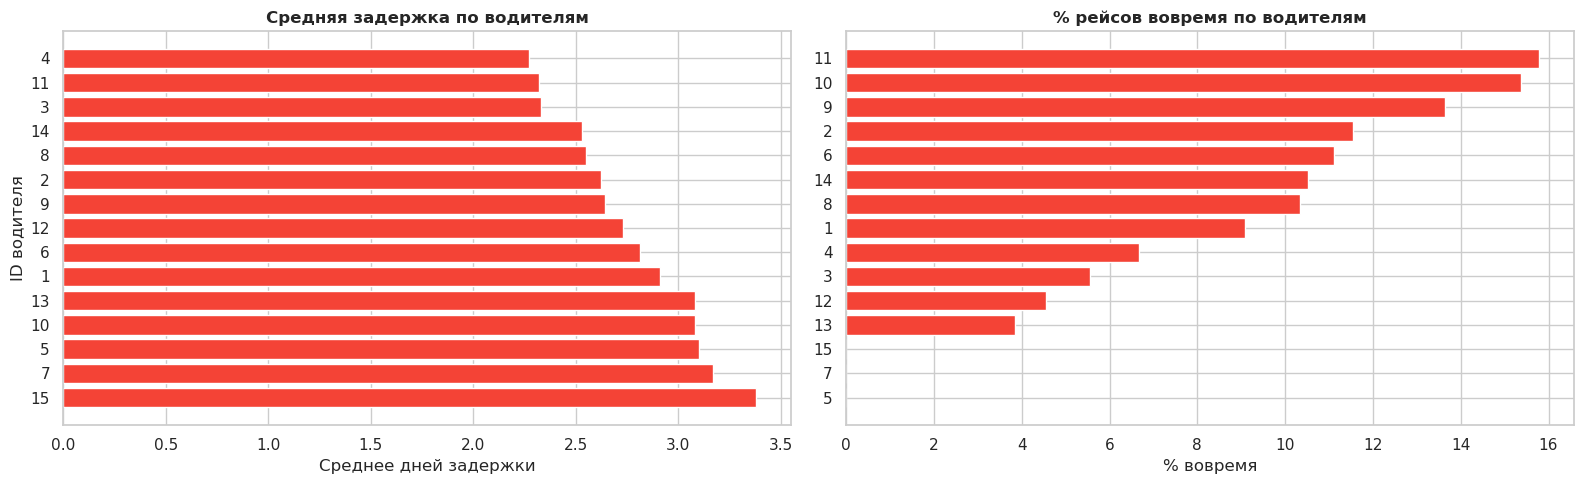

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dk = driver_kpi.sort_values('avg_delay', ascending=False).head(15)

bar_colors = ['#F44336' if d > 2 else '#FF9800' if d > 1 else '#4CAF50'
              for d in dk['avg_delay']]

axes[0].barh(dk['driver_id'].astype(str), dk['avg_delay'], color=bar_colors)
axes[0].set_title('Средняя задержка по водителям', fontweight='bold')
axes[0].set_xlabel('Среднее дней задержки')
axes[0].set_ylabel('ID водителя')

dk2 = driver_kpi.sort_values('pct_on_time', ascending=True).head(15)
axes[1].barh(dk2['driver_id'].astype(str), dk2['pct_on_time'],
             color=['#4CAF50' if p > 60 else '#FF9800' if p > 40 else '#F44336'
                    for p in dk2['pct_on_time']])
axes[1].set_title('% рейсов вовремя по водителям', fontweight='bold')
axes[1].set_xlabel('% вовремя')

plt.tight_layout()
plt.show()

## 7. Анализ маршрутов


In [9]:
route_analysis = (
    df.groupby('route_id')
    .agg(
        trips         = ('delivery_id',  'count'),
        avg_delay     = ('delay_days',   'mean'),
        avg_cost_km   = ('cost_per_km',  'mean'),
        avg_volume    = ('volume_t',     'mean'),
        main_weather  = ('weather',      lambda x: x.mode()[0]),
        main_road     = ('road_type',    lambda x: x.mode()[0]),
    )
    .reset_index()
    .sort_values('avg_delay', ascending=False)
    .round(2)
)

print('Топ-10 маршрутов по задержке:')
display(route_analysis.head(10))

Топ-10 маршрутов по задержке:


,route_id,trips,avg_delay,avg_cost_km,avg_volume,main_weather,main_road
5,RT-006,15,3.13,290.24,25.72,snow,highway
2,RT-003,15,3.07,151.71,28.84,snow,highway
3,RT-004,15,3.00,207.81,27.49,snow,highway
16,RT-017,15,2.93,219.84,27.33,clear,highway
1,RT-002,15,2.93,163.84,26.03,snow,highway
13,RT-014,15,2.87,262.85,30.92,clear,gravel
18,RT-019,15,2.87,146.27,27.42,clear,highway
7,RT-008,15,2.87,227.22,24.91,clear,highway
17,RT-018,15,2.80,153.95,33.08,clear,highway
15,RT-016,15,2.80,217.67,26.92,clear,gravel


## 8. Сохранение витрин в PostgreSQL


In [10]:
driver_kpi.to_sql('analytics_logistics', engine, if_exists='replace', index=False)
print(f'Записано {len(driver_kpi)} строк в analytics_logistics ')

route_analysis.to_sql('analytics_routes', engine, if_exists='replace', index=False)
print(f'Записано {len(route_analysis)} строк в analytics_routes ')

weather_delay.to_sql('analytics_weather_delay', engine, if_exists='replace', index=False)
print(f'Записано {len(weather_delay)} строк в analytics_weather_delay ')

Записано 15 строк в analytics_logistics 
Записано 20 строк в analytics_routes 
Записано 4 строк в analytics_weather_delay 
